In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
from src import visualization
from src import data_loading
from src.utils import set_random_seed

from sklearn.preprocessing import StandardScaler

config.make_all_dirs()
set_random_seed(42)

sns.set(style="whitegrid")


[utils] Random seed set to 42


In [2]:
results_folder = config.EXPERIMENT_RESULTS_DIR
print("Results folder:", results_folder)

val_results_path = os.path.join(results_folder, "per_pipeline_val_results.csv")
df_val_results = pd.read_csv(val_results_path)
print("Validation results shape:", df_val_results.shape)
df_val_results.head()


Results folder: C:\Users\Arafat\Desktop\IMA Project\experiments\results
Validation results shape: (40, 6)


,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value
0,0.571716,0.577817,0.572135,0.569001,RawPixels,1
1,0.498192,0.515854,0.498469,0.495947,RawPixels,3
2,0.493773,0.507788,0.494062,0.488444,RawPixels,5
3,0.468059,0.494193,0.468237,0.464351,RawPixels,7
4,0.460024,0.488431,0.460199,0.455492,RawPixels,9


In [3]:
# robustness CSVs 
gauss_path = os.path.join(results_folder, "robustness_gaussian_noise.csv")
sp_path = os.path.join(results_folder, "robustness_salt_pepper.csv")
bright_path = os.path.join(results_folder, "robustness_brightness.csv")
trsize_path = os.path.join(results_folder, "sensitivity_train_size.csv")

df_gauss = pd.read_csv(gauss_path) if os.path.exists(gauss_path) else None
df_sp = pd.read_csv(sp_path) if os.path.exists(sp_path) else None
df_bright = pd.read_csv(bright_path) if os.path.exists(bright_path) else None
df_trsize = pd.read_csv(trsize_path) if os.path.exists(trsize_path) else None

df_gauss.head() if df_gauss is not None else print("No gaussian robustness file")


,accuracy,macro_precision,macro_recall,macro_f1,noise_type,sigma
0,0.969867,0.969914,0.969912,0.969893,gaussian,0.00
1,0.229008,0.266419,0.229193,0.201380,gaussian,0.02
2,0.224588,0.206129,0.224069,0.172845,gaussian,0.05
3,0.256328,0.213667,0.255521,0.197400,gaussian,0.10
4,0.253114,0.223699,0.252077,0.138575,gaussian,0.15


### Table of best validation metrics per pipeline

In [4]:
# Here I pick, for each pipeline, the row with the best validation macro F1

best_rows = []
for pipe_name in df_val_results["pipeline"].unique():
    temp_df = df_val_results[df_val_results["pipeline"] == pipe_name]
    best_idx = temp_df["macro_f1"].idxmax()
    best_rows.append(df_val_results.loc[best_idx])

df_best_per_pipeline = pd.DataFrame(best_rows).reset_index(drop=True)
print("Best validation performance per pipeline:")
df_best_per_pipeline


Best validation performance per pipeline:


,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value
0,0.571716,0.577817,0.572135,0.569001,RawPixels,1
1,0.894737,0.899283,0.895020,0.893401,GrayHist,3
2,0.964243,0.964391,0.964334,0.964118,ColorHists,1
3,0.772599,0.770746,0.773054,0.768210,Texture_LBP_GLCM,1
4,0.799518,0.800708,0.799984,0.795155,EdgesAndTexture,3
5,0.406589,0.425939,0.406759,0.406432,Frequency_FFT_DCT,1
6,0.861792,0.862059,0.862119,0.859946,Morphology_GrayHist,1
7,0.928887,0.930937,0.929091,0.928289,Combo_BestGuess,3


In [5]:
# Sort by macro_f1 to see ranking
df_best_sorted = df_best_per_pipeline.sort_values("macro_f1", ascending=False)
df_best_sorted


,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value
2,0.964243,0.964391,0.964334,0.964118,ColorHists,1
7,0.928887,0.930937,0.929091,0.928289,Combo_BestGuess,3
1,0.894737,0.899283,0.895020,0.893401,GrayHist,3
6,0.861792,0.862059,0.862119,0.859946,Morphology_GrayHist,1
4,0.799518,0.800708,0.799984,0.795155,EdgesAndTexture,3
3,0.772599,0.770746,0.773054,0.768210,Texture_LBP_GLCM,1
0,0.571716,0.577817,0.572135,0.569001,RawPixels,1
5,0.406589,0.425939,0.406759,0.406432,Frequency_FFT_DCT,1


### saving CSV table

In [6]:
tables_folder = config.TABLES_DIR
if not os.path.exists(tables_folder):
    os.makedirs(tables_folder, exist_ok=True)

table_path_csv = os.path.join(tables_folder, "best_validation_per_pipeline.csv")
df_best_sorted.to_csv(table_path_csv, index=False)
print("Saved best-per-pipeline table as CSV:", table_path_csv)


Saved best-per-pipeline table as CSV: C:\Users\Arafat\Desktop\IMA Project\reports\tables\best_validation_per_pipeline.csv


### visualizing best validation accuracy per pipeline

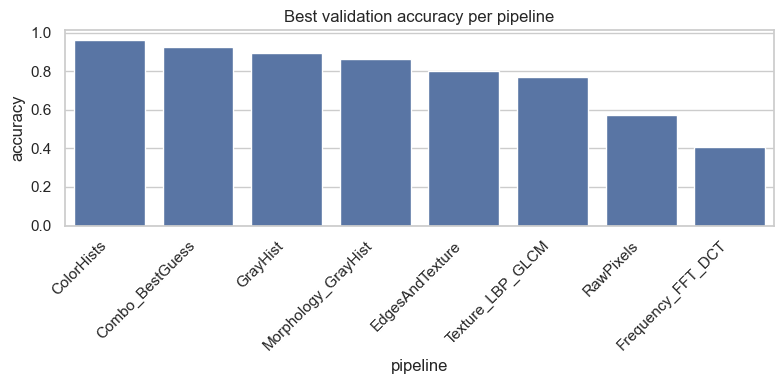

In [8]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_best_sorted, x="pipeline", y="accuracy")
plt.xticks(rotation=45, ha="right")
plt.title("Best validation accuracy per pipeline")
plt.tight_layout()
plt.show()


### visualizing line plot of accuracy vs k for a few pipelines

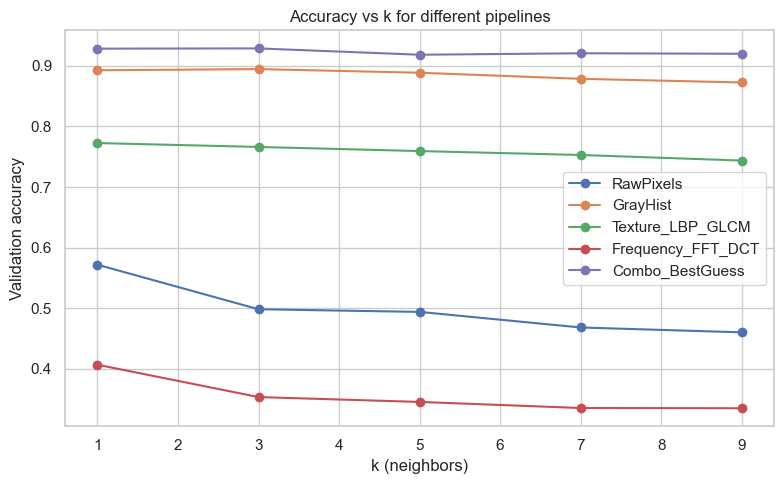

In [9]:
selected_for_plot = ["RawPixels", "GrayHist", "Texture_LBP_GLCM", "Frequency_FFT_DCT", "Combo_BestGuess"]

plt.figure(figsize=(8,5))
for pipe_name in selected_for_plot:
    temp_df = df_val_results[df_val_results["pipeline"] == pipe_name].sort_values("k_value")
    plt.plot(temp_df["k_value"], temp_df["accuracy"], marker="o", label=pipe_name)

plt.xlabel("k (neighbors)")
plt.ylabel("Validation accuracy")
plt.title("Accuracy vs k for different pipelines")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### robustness plots

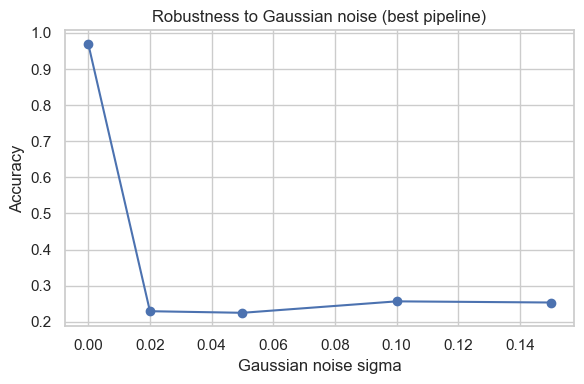

In [10]:
if df_gauss is not None:
    plt.figure(figsize=(6,4))
    plt.plot(df_gauss["sigma"], df_gauss["accuracy"], marker="o")
    plt.xlabel("Gaussian noise sigma")
    plt.ylabel("Accuracy")
    plt.title("Robustness to Gaussian noise (best pipeline)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


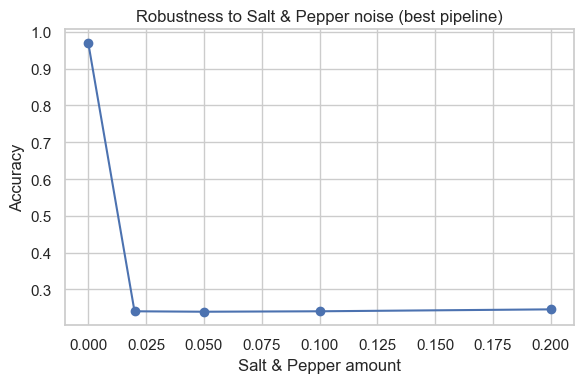

In [11]:
if df_sp is not None:
    plt.figure(figsize=(6,4))
    plt.plot(df_sp["amount"], df_sp["accuracy"], marker="o")
    plt.xlabel("Salt & Pepper amount")
    plt.ylabel("Accuracy")
    plt.title("Robustness to Salt & Pepper noise (best pipeline)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


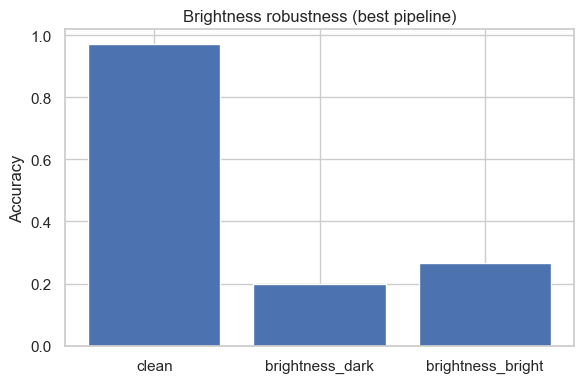

In [12]:
if df_bright is not None:
    plt.figure(figsize=(6,4))
    df_temp = df_bright.copy()
    # I also add the clean metrics row manually for comparison
    clean_acc = df_gauss[df_gauss["sigma"] == 0.0]["accuracy"].iloc[0] if df_gauss is not None else None
    clean_f1 = df_gauss[df_gauss["sigma"] == 0.0]["macro_f1"].iloc[0] if df_gauss is not None else None

    cases = ["clean", "brightness_dark", "brightness_bright"]
    accs = [clean_acc, df_temp[df_temp["case"]=="brightness_dark"]["accuracy"].iloc[0],
            df_temp[df_temp["case"]=="brightness_bright"]["accuracy"].iloc[0]]

    plt.bar(cases, accs)
    plt.ylabel("Accuracy")
    plt.title("Brightness robustness (best pipeline)")
    plt.tight_layout()
    plt.show()


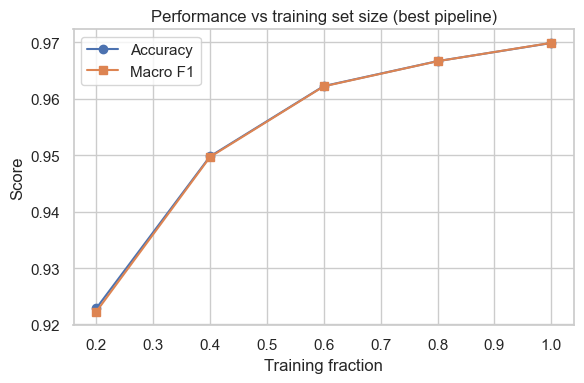

In [13]:
if df_trsize is not None:
    plt.figure(figsize=(6,4))
    plt.plot(df_trsize["train_fraction"], df_trsize["accuracy"], marker="o", label="Accuracy")
    plt.plot(df_trsize["train_fraction"], df_trsize["macro_f1"], marker="s", label="Macro F1")
    plt.xlabel("Training fraction")
    plt.ylabel("Score")
    plt.title("Performance vs training set size (best pipeline)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### PCA and t-SNE visualization for best pipeline

Visualizing with PCA...


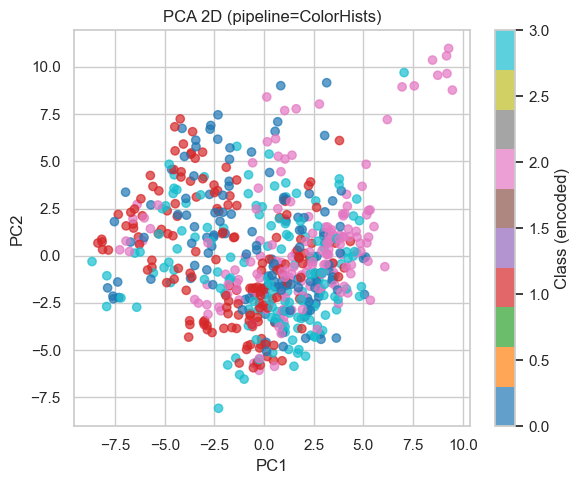

In [14]:
from src.knn import MyKNNClassifier
from src import visualization as vis
from sklearn.preprocessing import LabelEncoder

# load features for best pipeline again
from src import features as feat_mod

# reuse helper from previous notebook logic:
def load_pipeline_features(pipe_name: str):
    pipe_folder = os.path.join(config.FEATURES_DIR, pipe_name)
    npz_path = os.path.join(pipe_folder, f"{pipe_name}_features.npz")
    data = np.load(npz_path)
    return data["feat_train"], data["feat_val"], data["feat_test"], data["y_train"], data["y_val"], data["y_test"]

feat_train_best, feat_val_best, feat_test_best, y_train_best, y_val_best, y_test_best = \
    load_pipeline_features(df_best_sorted.iloc[0]["pipeline"])

# For visualization I only use a subset for speed (like 500 samples)
X_vis = np.vstack([feat_train_best, feat_val_best, feat_test_best])
y_vis = np.concatenate([y_train_best, y_val_best, y_test_best])

if X_vis.shape[0] > 600:
    idxs = np.random.choice(X_vis.shape[0], size=600, replace=False)
    X_vis_small = X_vis[idxs]
    y_vis_small = y_vis[idxs]
else:
    X_vis_small = X_vis
    y_vis_small = y_vis

# scale
scaler = StandardScaler()
X_vis_small_scaled = scaler.fit_transform(X_vis_small)

print("Visualizing with PCA...")
vis.plot_pca_scatter(X_vis_small_scaled, y_vis_small, title=f"PCA 2D (pipeline={df_best_sorted.iloc[0]['pipeline']})")


Visualizing with t-SNE (this can be slower)...


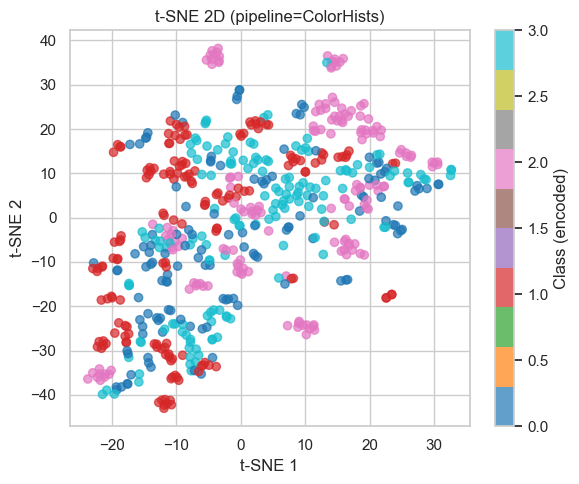

In [15]:
print("Visualizing with t-SNE")
vis.plot_tsne_scatter(X_vis_small_scaled, y_vis_small, title=f"t-SNE 2D (pipeline={df_best_sorted.iloc[0]['pipeline']})")


### saving final figures

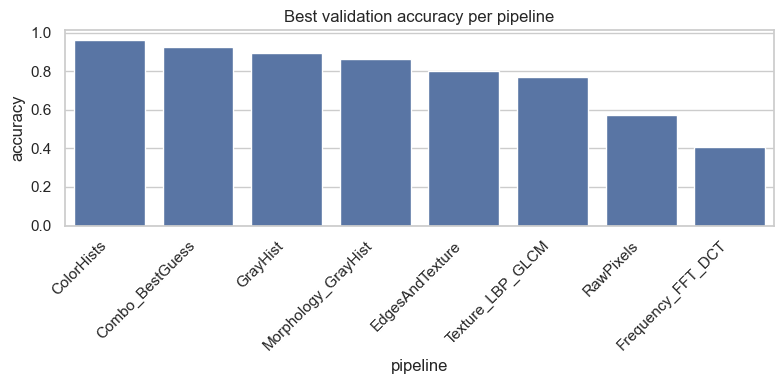

Saved figure to: C:\Users\Arafat\Desktop\IMA Project\reports\figures\best_validation_accuracy_per_pipeline.png


In [16]:
figures_folder = config.FIGURES_DIR
if not os.path.exists(figures_folder):
    os.makedirs(figures_folder, exist_ok=True)


plt.figure(figsize=(8,4))
sns.barplot(data=df_best_sorted, x="pipeline", y="accuracy")
plt.xticks(rotation=45, ha="right")
plt.title("Best validation accuracy per pipeline")
plt.tight_layout()
save_path = os.path.join(figures_folder, "best_validation_accuracy_per_pipeline.png")
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved figure to:", save_path)
